# DDM MIMO

You can open this workbook in Google Colab to experiment with mmWrt 
[![](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/matt-chv/mmWrt/blob/main/docs/MIMO_DDM.ipynb)

Below is an intro to mmWrt for simple targets position in (X,Y) plane based on 2D FFT (Range, Azimuth) FFTs with a DDM MIMO.

## DDM MIMO ULA

In [1]:
# Install a pip package in the current Jupyter kernel
import sys
from os.path import abspath, basename, join, pardir
import datetime

# hack to handle if running from git cloned folder or stand alone (like Google Colab)
cw = basename(abspath(join(".")))
dp = abspath(join(".",pardir))
if cw=="docs" and basename(dp) == "mmWrt":
    # running from cloned folder
    print("running from git folder, using local path (latest) mmWrt code", dp)
    sys.path.insert(0, dp)
else:
    print("running standalone, need to ensure mmWrt is installed")
    !{sys.executable} -m pip install mmWrt

from os.path import abspath, join, pardir
import sys
from numpy.fft import fft, fftshift
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
from numpy import arange, cos, sin, pi, zeros

from mmWrt.Scene import Antenna, Medium, Radar, Receiver, Scatterer, TransmitterDDM
from mmWrt.Raytracing import rt_points
from mmWrt import __version__ as mmWrt_version
print("version:", mmWrt_version)

print("last run on ", datetime.datetime.now())

running from git folder, using local path (latest) mmWrt code c:\git\mmWrt
version: 0.0.11-pre.3
last run on  2026-06-27 12:22:53.599929


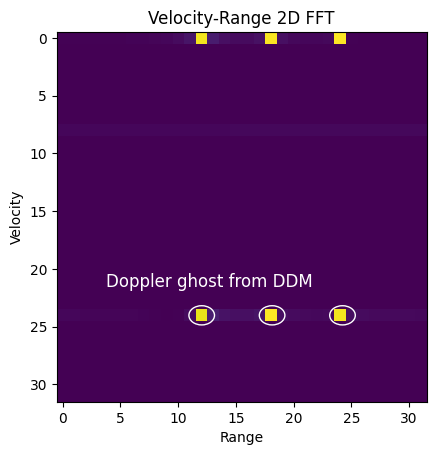

In [42]:
from scipy.fft import fft, fft2
from numpy import pi, array, abs as np_abs

f0 = 61e9
# Number of ADC samples
NA = 64
# Number of TX channels
NT = 2
# Number of RX channels
NR = 8
# Number of chirps (used for speed)
NC=32

tic0 = 1.2e-3

void = Medium()
c = void.v
lambda0 = c/f0
_fs = 2e5/2
_k = 28e10 # chirp slope
chirp_start_freq0 = f0
chirp_period0 = 1.2e-3
chirp_bw0 = 0.2e9
chirp_end_time0 = chirp_bw0/_k
chirp_slope0 = _k
chirp_count0 = NC

TXs = [Antenna(x=NR*lambda0/2*i) for i in range(NT)]
RXs = [Antenna(x=lambda0/2*i) for i in range(NR)]

radar = Radar(transmitter=TransmitterDDM(chirp_start_freq=chirp_start_freq0,
                                         chirp_end_time=chirp_end_time0,
                                         chirp_slope=chirp_slope0,
                                         antennas=TXs,
                                         chirp_period=chirp_period0,
                                         chirp_count=chirp_count0,
                                         conf={"TX_phaser_slopes":
                                               [0, pi/2]}),
              receiver=Receiver(adc_sample_rate=_fs,
                                adc_sample_count_max=2048,
                                adc_sample_count=NA,
                                antennas=RXs),
              debug=False)
r1, theta1 = 10.1, 0
x1, y1 = r1*cos(theta1), r1*sin(theta1)
r2, theta2 = 15.1, pi/2
x2, y2 = r2*cos(theta2), r2*sin(theta2)
r3, theta3 = 20.1, pi*0.8
x3, y3 = r3*cos(theta3), r3*sin(theta3)

target1 = Scatterer(x1, y1, 0)  # 0 degrees on x-axis <=> -pi/2 vs bore sight
target2 = Scatterer(x2, y2, 0) # pi/2 degrees vs x-ax <=> 0 degree vs bore sight
target3 = Scatterer(x3, y3, 0) # 180 degrees on x-axis <=> pi/2 vs boresight
scatterers = [target1, target2, target3]

bb = rt_points([radar],
               scatterers,
               radar,
               debug=False)

fast_time_axis = 3
slow_time_axis = 1
cube = bb["adc_cube"][0, :, 0, :]
# bb[frame_i, chirp_i, tx_i, rx_i, adc_i]
# virtual_cube_RX0 = bb["adc_cube"][0,:,0,:]
#virtual_cube_RX1 = bb["adc_cube"][0,:,1,:]
Z = fft2(cube)[:, :NA//2]  # , axis=fast_time_axis), axis=slow_time_axis)
Z = fft(fft(bb["adc_cube"],axis=fast_time_axis),axis=slow_time_axis)
#Z0 = abs(fft2(virtual_cube_RX0))
#Z1 = abs(fft2(virtual_cube_RX1))

fig, (ax0) = plt.subplots(ncols=1)
ax0.set_xlabel("Range")
ax0.set_ylabel("Velocity")
ax0.set_title('Velocity-Range 2D FFT')
ax0.imshow(np_abs(Z[0,:,0,:NA//2]))  #, cmap='bone_r')
sub_doppler_ghost1 = plt.Circle((0.45, 0.29), 0.02, fill=False, color="white")
sub_doppler_ghost2 = plt.Circle((0.56, 0.29), 0.02, fill=False, color="white")
sub_doppler_ghost3 = plt.Circle((0.67, 0.29), 0.02, fill=False, color="white")
fig.text(0.3, 0.35, f"Doppler ghost from DDM", color="white", fontsize=12)
fig.add_artist(sub_doppler_ghost1)
fig.add_artist(sub_doppler_ghost2)
fig.add_artist(sub_doppler_ghost3)
plt.show()


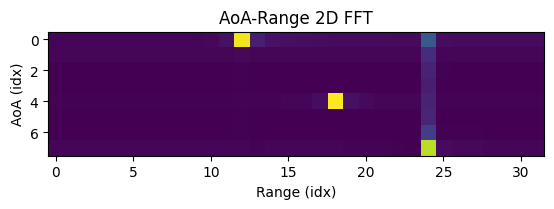

In [43]:
from scipy.signal import find_peaks
# generate virtual antennas

# important to declare the zeros as complex otherwise assignement
# forces a type cast to real
# virtual_cube = zeros(( NC//NT, NT * NR, NA//2)).astype(complex)

"""for tx_idx in range(NT):
    for rx_idx in range(NR):
        # virtual antenna index =
        # tx_idx*NT+ rx_idx
        virtual_rx_idx = tx_idx*NR+ rx_idx
        virtual_cube[:,virtual_rx_idx,:] = Z[0, tx_idx*NC//NT:(tx_idx+1)*NC//NT, 0, rx_idx, :NA//2]"""
virtual_cube = Z[0,:,:,:]
#virtual_cube = virtual_cube[0,0, :, :]
#doppler_axis=None as removed
rx_axis = 1
# range_axis=1
A = fftshift(fft(virtual_cube, axis=rx_axis), axes=rx_axis)
# plot AoA at zero Doppler
plt.xlabel("Range (idx)")
plt.ylabel("AoA (idx)")
plt.title('AoA-Range 2D FFT')
plt.imshow(abs(A[0,:,:NA//2]))
plt.show()

## Dummy sub doppler

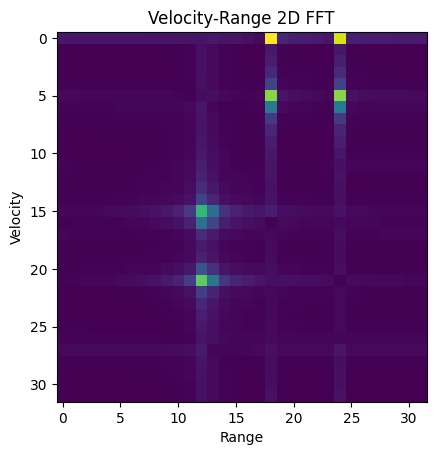

range peaks (array([13, 18, 24, 40, 46, 51]), {})
first range bin 13
doppler peaks (array([15, 21]), {'peak_heights': array([358.50552368, 393.99209595])})
sub doppler width 10
min 15
12.0


In [73]:
from numpy import mean, concatenate, array, pi

radar = Radar(transmitter=TransmitterDDM(chirp_end_time=chirp_end_time0,
                                          chirp_slope=chirp_slope0,
                                          chirp_period=chirp_period0,
                                          chirp_count=chirp_count0,
                                          antennas=TXs,
                                          conf={"TX_phaser_slopes":
                                               [0, -pi/3]}),
              receiver=Receiver(adc_sample_rate=_fs, 
                                adc_sample_count_max=2048,
                                adc_sample_count=NA,
                                antennas=RXs),
              debug=False)

r1, theta1 = 10.1, 0
x1, y1 = r1*cos(theta1), r1*sin(theta1)
r2, theta2 = 15.1, pi/2
x2, y2 = r2*cos(theta2), r2*sin(theta2)
r3, theta3 = 20.1, pi*0.8
x3, y3 = r3*cos(theta3), r3*sin(theta3)

v1 = 1.
scatterer1 = Scatterer(x1, y1, 0, xt= lambda t: x1+v1*t)  # 0 degrees on x-axis <=> -pi/2 vs bore sight
scatterer2 = Scatterer(x2, y2, 0) # pi/2 degrees vs x-ax <=> 0 degree vs bore sight
scatterer3 = Scatterer(x3, y3, 0) # 180 degrees on x-axis <=> pi/2 vs boresight
scatterers = [scatterer1, scatterer2, scatterer3]

bb = rt_points([radar],
               scatterers,
               radar,
               debug=False)
fast_time_axis = 3
slow_time_axis = 1
cube = bb["adc_cube"]
# bb[frame_i, chirp_i, tx_i, rx_i, adc_i]
virtual_cube_RX0 = bb["adc_cube"][0,:,0,:]
virtual_cube_RX1 = bb["adc_cube"][0,:,1,:]
Z = fft(fft(cube, axis=fast_time_axis), axis=slow_time_axis)
Z0 = abs(fft2(virtual_cube_RX0))
Z1 = abs(fft2(virtual_cube_RX1))

fig, (ax0) = plt.subplots(ncols=1)
ax0.set_xlabel("Range")
ax0.set_ylabel("Velocity")
ax0.set_title('Velocity-Range 2D FFT')
ax0.imshow(abs(Z[0, :, 0,:NA//2]))
plt.show()

# find peaks
range_pks = find_peaks(abs(Z[0,0,0,:]))
print("range peaks", range_pks)
range_bin_idx = range_pks[0][0]
print("first range bin",range_bin_idx)
doppler_peaks = find_peaks(abs(Z[0,:,0,range_bin_idx]), height=100)
print("doppler peaks", doppler_peaks)
doppler_peaks = doppler_peaks[0]
sub_dop_width = NC//(NT+1)
print("sub doppler width", sub_dop_width)
print("min", min(doppler_peaks))
if min(doppler_peaks) >= sub_dop_width:
    dopplers = [d-(idx+1)*sub_dop_width-1 for idx,d in enumerate(doppler_peaks)]
    # print("dopplers shifted", dopplers)
    print(sub_dop_width+mean(dopplers))

In [74]:
# non regression hook
# ensure first range bin does not have velocity 
# < NF//NT
assert min(doppler_peaks) == 15
